In [1]:
import os
import pandas as pd
import numpy as np
import pylab as plt
import seaborn as sns
from adjustText import adjust_text

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
import jupyter_black
jupyter_black.load()

In [4]:
plt.style.use("../src/mpl_style.txt")

### Subgroup Analysis on Countries

In [5]:
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

In [6]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../data/results/", BASELINE, VERSION)
secs = next(os.walk(RESULTS_PATH))[1]

CUTOFF_VERSION = "subsubopt"

In [7]:
freqs_dfs = {}

for sec in ["abstract", "full"]:
    freqs_dfs[sec] = utils.get_country_frequency(RESULTS_PATH, sec, CUTOFF_VERSION)
    p = freqs_dfs[sec]["projection"]
    q = freqs_dfs[sec]["frequency"]
    totals = freqs_dfs[sec]["paper_counts"]
    reg_se = freqs_dfs[sec]["regression se"]
    freqs_dfs[sec]["regression se (ds)"] = list(
        map(utils.se, p, q, totals, ["regression"] * len(p), reg_se)
    )

loading country freqs
loading country freqs


In [8]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "english"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
20,english,2018,0.899472,0.898208,0.001264,0.012416,0.001764,26897.0,0.024847
42,english,2019,0.902838,0.904200,-0.001361,-0.014212,0.001590,28539.0,0.024866
64,english,2020,0.909140,0.910191,-0.001051,-0.011702,0.001528,33336.0,0.024565
86,english,2021,0.917313,0.916182,0.001131,0.013495,0.001590,39425.0,0.024982
108,english,2022,0.922191,0.922174,0.000017,0.000225,0.001764,42899.0,0.028102
130,english,2023,0.931874,0.928165,0.003709,0.051630,0.002021,42479.0,0.031647
152,english,2024,0.948768,0.934156,0.014612,0.221920,0.002334,44249.0,0.031842
174,english,2025,0.962530,0.940148,0.022383,0.373963,0.002683,48358.0,0.031552


In [9]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "non-english"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
21,non-english,2018,0.752084,0.747125,0.004959,0.019610,0.008862,56982.0,0.035096
43,non-english,2019,0.757589,0.757584,0.000006,0.000023,0.007988,62983.0,0.033697
65,non-english,2020,0.758164,0.768042,-0.009878,-0.042583,0.007675,76092.0,0.035140
87,non-english,2021,0.778403,0.778500,-0.000097,-0.000438,0.007988,89179.0,0.036623
109,non-english,2022,0.793969,0.788959,0.005010,0.023740,0.008862,99416.0,0.041445
131,non-english,2023,0.829769,0.799417,0.030352,0.151317,0.010153,86869.0,0.043427
153,non-english,2024,0.903284,0.809875,0.093409,0.491303,0.011724,89943.0,0.031794
175,non-english,2025,0.949808,0.820334,0.129474,0.720638,0.013477,97166.0,0.021315


In [10]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "Canada"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
6,Canada,2018,0.908827,0.900887,0.007940,0.080110,0.011222,2412.0,0.119775
28,Canada,2019,0.893014,0.905066,-0.012052,-0.126953,0.010116,2504.0,0.136578
50,Canada,2020,0.908836,0.909245,-0.000409,-0.004508,0.009719,2851.0,0.122883
72,Canada,2021,0.918639,0.913424,0.005215,0.060237,0.010116,3379.0,0.122507
94,Canada,2022,0.916909,0.917603,-0.000694,-0.008419,0.011222,3778.0,0.147764
116,Canada,2023,0.941226,0.921782,0.019444,0.248590,0.012857,3555.0,0.133411
138,Canada,2024,0.949987,0.925961,0.024026,0.324505,0.014846,3798.0,0.143623
160,Canada,2025,0.962558,0.930140,0.032418,0.464041,0.017066,4112.0,0.137614


In [11]:
freqs_dfs["full"][freqs_dfs["full"]["cutoff"] == "Taiwan"]

,cutoff,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds)
16,Taiwan,2018,0.685598,0.687368,-0.001769,-0.005660,0.020848,985.0,0.082076
38,Taiwan,2019,0.713060,0.704102,0.008958,0.030274,0.018792,1048.0,0.077606
60,Taiwan,2020,0.722423,0.720837,0.001587,0.005683,0.018055,1105.0,0.080400
82,Taiwan,2021,0.714602,0.737571,-0.022969,-0.087526,0.018792,1355.0,0.090831
104,Taiwan,2022,0.768500,0.754305,0.014194,0.057772,0.020848,1472.0,0.091621
126,Taiwan,2023,0.812658,0.771040,0.041618,0.181771,0.023884,1184.0,0.098683
148,Taiwan,2024,0.913082,0.787774,0.125307,0.590444,0.027579,1138.0,0.066190
170,Taiwan,2025,0.961270,0.804509,0.156762,0.801885,0.031703,1290.0,0.042278


In [12]:
country_alt_names = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Korea, Republic of": "South Korea",
    "Iran, Islamic Republic of": "Iran",
    "english": "NES",
    "non-english": "NNES",
}

In [13]:
df = pd.concat(freqs_dfs, names=["section"]).reset_index(level=0).reset_index(drop=True)
df["country"] = [
    country_alt_names[c] if c in country_alt_names.keys() else c for c in df["cutoff"]
]
df = df.drop("cutoff", axis=1)
df["section"] = pd.Categorical(
    df["section"],
    categories=[
        "abstract",
        "introduction",
        "methods",
        "results",
        "discussion",
        "full",
    ],
    ordered=True,
)
df

,section,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds),country
0,abstract,2018,0.608603,0.597407,0.011195,0.027808,0.016804,16366.0,0.041669,China
1,abstract,2018,0.736757,0.733183,0.003573,0.013392,0.006365,15384.0,0.027037,USA
2,abstract,2018,0.722025,0.716563,0.005462,0.019270,0.007099,6478.0,0.031448,UK
3,abstract,2018,0.546788,0.546563,0.000225,0.000495,0.005948,5385.0,0.019893,Japan
4,abstract,2018,0.706512,0.709937,-0.003425,-0.011807,0.009957,4483.0,0.041905,Germany
...,...,...,...,...,...,...,...,...,...,...
347,full,2025,0.937759,0.712241,0.225519,0.783706,0.028413,963.0,0.034468,Iran
348,full,2025,0.897353,0.691058,0.206295,0.667746,0.045326,1850.0,0.053831,Türkiye
349,full,2025,0.936937,0.878593,0.058344,0.480567,0.007798,887.0,0.075050,Poland
350,full,2025,0.962530,0.940148,0.022383,0.373963,0.002683,48358.0,0.031552,NES


In [14]:
exclude = ["Türkiye", "Poland"]
df_filtered = df[
    (df["time"].between(2022, 2025))
    & (df["section"].isin(["abstract", "full"]))
    & (~df["country"].isin(exclude))
]
df_filtered

,section,time,frequency,projection,diff,usage estimate,regression se,paper_counts,regression se (ds),country
88,abstract,2022,0.660328,0.651300,0.009028,0.025891,0.016804,36234.0,0.047481,China
89,abstract,2022,0.773998,0.770390,0.003608,0.015715,0.006365,26282.0,0.029508,USA
90,abstract,2022,0.737715,0.734018,0.003697,0.013898,0.007099,8200.0,0.032034,UK
91,abstract,2022,0.564533,0.563074,0.001458,0.003338,0.005948,7685.0,0.018752,Japan
92,abstract,2022,0.738003,0.735994,0.002009,0.007612,0.009957,7251.0,0.042230,Germany
...,...,...,...,...,...,...,...,...,...,...
345,full,2025,0.974384,0.921867,0.052517,0.672146,0.013754,2068.0,0.072854,Switzerland
346,full,2025,0.961270,0.804509,0.156762,0.801885,0.031703,1290.0,0.042278,Taiwan
347,full,2025,0.937759,0.712241,0.225519,0.783706,0.028413,963.0,0.034468,Iran
350,full,2025,0.962530,0.940148,0.022383,0.373963,0.002683,48358.0,0.031552,NES


In [15]:
countries_in_order = [
    "South Korea",
    "China",
    "Taiwan",
    "Iran",
    "Spain",
    "India",
    "Switzerland",
    "Brazil",
    "Italy",
    "Japan",
    "Germany",
    "Netherlands",
    "Sweden",
    "Canada",
    "Australia",
    "France",
    "USA",
    "UK",
    "NES",
    "NNES",
]

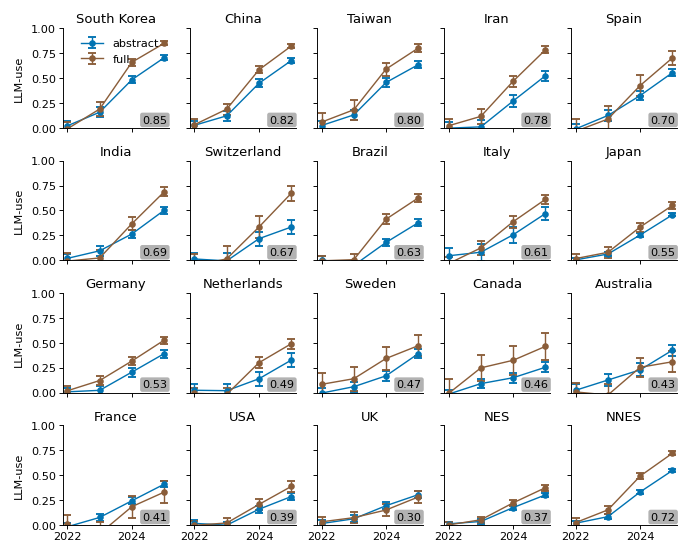

In [16]:
countries = df_filtered["country"].unique()
n = len(countries)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols, nrows),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes = axes.flatten()

for i, country in enumerate(countries_in_order):
    ax = axes[i]
    sub = df_filtered[df_filtered["country"] == country]

    for section in ["abstract", "full"]:
        sec_data = sub[sub["section"] == section].sort_values("time")

        ax.errorbar(
            sec_data["time"],
            sec_data["usage estimate"],
            yerr=sec_data["regression se (ds)"],
            color=colors[section],
            marker="o",
            linestyle="-",
            capsize=2,
            markersize=2.5,
            clip_on=True,
            label=section,
        )

    # Title
    ax.set_title(country)

    # Max usage annotation
    max_usage = sub["usage estimate"].max()
    ax.text(
        0.75,  # 0.05,
        0.05,  # 0.9,
        f"{max_usage:.2f}",
        transform=ax.transAxes,
        bbox=dict(
            facecolor="#666666", edgecolor="none", alpha=0.5, boxstyle="round,pad=.2"
        ),
    )

    ax.set_ylim([0, 1])

    if i % ncols == 0:
        ax.set_ylabel("LLM-use")

axes[0].legend()

# plt.tight_layout()
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"countries_individual_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()

In [17]:
df_full = df[(df["section"] == "full") & (df["time"].isin([2024, 2025]))]
df_full = df_full.pivot(
    index="country", columns="time", values="usage estimate"
).reset_index()

In [18]:
english_countries = ["USA", "UK", "Canada", "Australia", "NES"]
df_full["group"] = [
    "NES" if c in english_countries else "NNES" for c in df_full["country"]
]

In [19]:
df_full["ha"] = [
    "left",
    "left",
    "right",
    "right",
    "right",
    "right",
    "right",
    "right",
    "right",
    "left",
    "left",
    "left",
    "right",
    "left",
    "left",
    "left",
    "left",
    "right",
    "left",
    "left",
    "right",
    "right",
]
# df_full["ha"] = ["right"] * len(df_full)
df_full["va"] = [
    "top",
    "top",
    "top",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "center",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "bottom",
    "top",
    "top",
    "top",
    "top",
    "top",
    "top",
    "bottom",
]
# df_full["va"] = ["top"] * len(df_full)
df_full

time,country,2024,2025,group,ha,va
0,Australia,0.254433,0.309464,NES,left,top
1,Brazil,0.412554,0.626389,NNES,left,top
2,Canada,0.324505,0.464041,NES,right,top
3,China,0.583663,0.821765,NNES,right,bottom
4,France,0.183839,0.329718,NNES,right,bottom
5,Germany,0.317187,0.526702,NNES,right,bottom
6,India,0.366734,0.687055,NNES,right,bottom
7,Iran,0.468154,0.783706,NNES,right,bottom
8,Italy,0.386737,0.611601,NNES,right,center
9,Japan,0.333624,0.550753,NNES,left,bottom


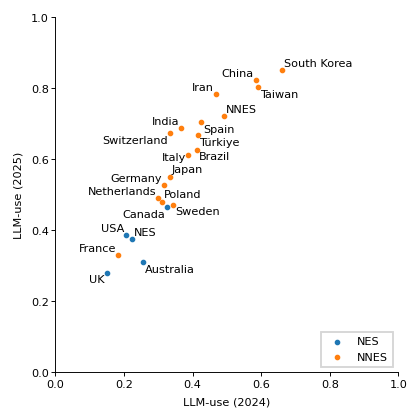

In [20]:
fig, ax = plt.subplots(
    figsize=(3, 3),
    layout="constrained",
)

for group, d in df_full.groupby("group"):
    ax.scatter(d[2024], d[2025], label=group)

for _, row in df_full.iterrows():
    x_offset = 1 if row["ha"] == "left" else -1
    y_offset = 1 if row["va"] == "bottom" else -1
    ax.annotate(
        row["country"],
        xy=(row[2024], row[2025]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        ha=row["ha"],
        va=row["va"],
    )

ax.set_xlabel("LLM-use (2024)")
ax.set_ylabel("LLM-use (2025)")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc="lower right", frameon=True)

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"countries_2024v2025_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()

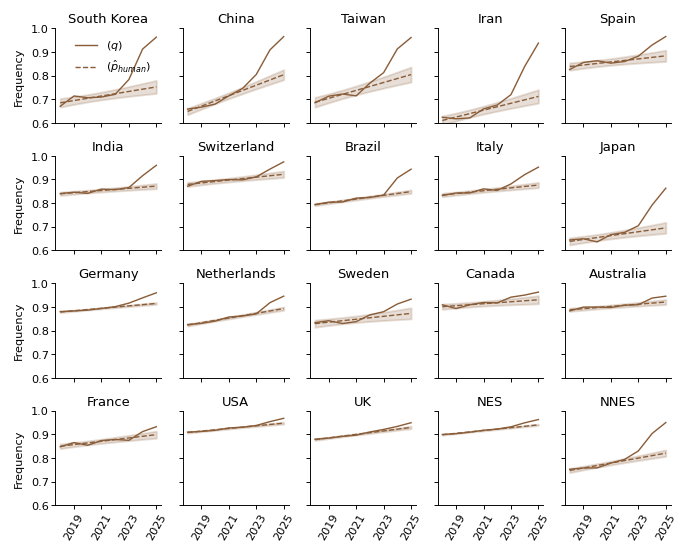

In [21]:
df_filtered = df[(df["section"] == "full") & (~df["country"].isin(exclude))]

countries = df_filtered["country"].unique()
n = len(countries)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols, nrows),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes = axes.flatten()

for i, country in enumerate(countries_in_order):
    ax = axes[i]
    sub = df_filtered[df_filtered["country"] == country].sort_values("time")

    ax.plot(
        sub["time"],
        sub["frequency"],
        color=colors["full"],
        label="($q$)",
    )

    ax.plot(
        sub["time"],
        sub["projection"],
        # yerr=sub["regression se"],
        color=colors["full"],
        linestyle="--",
        label="($\\hat{p}_{human}$)",
    )

    ax.fill_between(
        sub["time"],
        sub["projection"] - sub["regression se"],
        sub["projection"] + sub["regression se"],
        alpha=0.2,
        color=colors["full"],
    )

    # Title
    ax.set_title(country)

    ax.set_ylim([0.6, 1])
    ax.set_xticks(range(2019, 2026, 2))

    if i % ncols == 0:
        ax.set_ylabel("Frequency")
    if i >= ncols * (nrows - 1):
        ax.set_xticklabels(range(2019, 2026, 2), rotation=60)


axes[0].legend()

# plt.tight_layout()
plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        f"countries_individual_freqs_{CUTOFF_VERSION}.png",
    ),
    dpi=300,
)
plt.show()